# Notebook 2 — Preprocessing

*SWC ENC 2026 · ephys-pop module*

The raw voltage is a mess of nuisances that bury the spikes. Before we detect
anything we clean it up, following Kilosort's preprocessing: **three problems, three
tools**.

| nuisance | what it is | tool |
|---|---|---|
| slow drift / LFP | low-frequency signal shared across channels | **high-pass filter** |
| shared artefact | a fast signal identical on every channel (movement, reference) | **common average reference** |
| correlated noise | nearby channels share noise, so a threshold means different things on different channels | **whitening** |

The first tool, **filtering**, works in the language of *frequency*, and the third,
**whitening**, in the language of *covariance* — so we'll build both those languages up
from scratch before using them. By the end you will have:

1. seen a signal as a mix of **frequencies** (the Fourier view and the power spectrum),
2. understood what a **filter** does, and what a **Butterworth** filter is,
3. **high-pass filtered** the recording, **common-average-referenced** it, and
   **whitened** it — with a geometric picture of what whitening actually does.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

rec = ps.make_recording(n_units=6, duration_s=20.0, seed=0)
raw = rec.traces
print("raw traces:", raw.shape)

raw traces: (600000, 32)


## 1. A signal is a mixture of frequencies

A voltage trace looks like a squiggle in *time*. But there's a second, equally valid
way to describe it: by *what frequencies it is made of* — how much slow wave, how much
fast wiggle. This **frequency view** is the whole key to separating spikes (fast)
from drift (slow).

To see it, let's build a signal by hand out of three pure sine waves — a slow 4 Hz
wave, a medium 40 Hz wave, and a fast 200 Hz wave — and add them up.

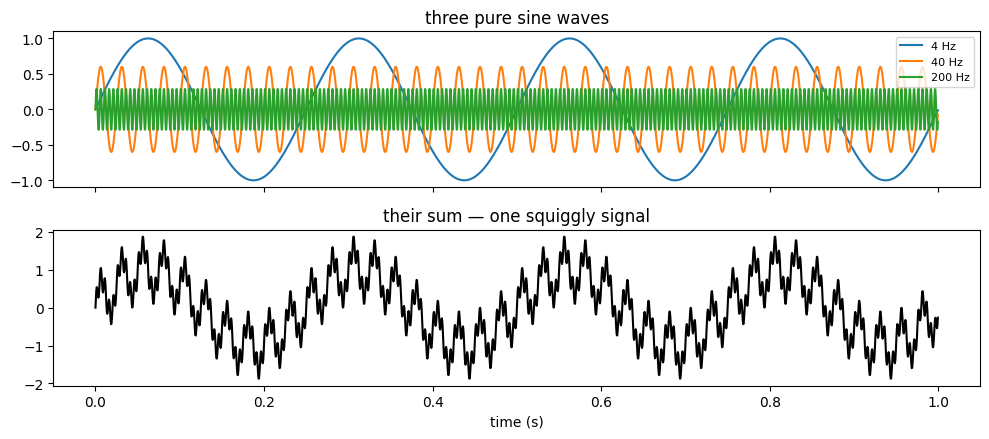

In [2]:
fs_demo = 2000.0                     # samples per second, for this toy example
t = np.arange(0, 1.0, 1 / fs_demo)   # one second
slow  = 1.0 * np.sin(2 * np.pi * 4   * t)
med   = 0.6 * np.sin(2 * np.pi * 40  * t)
fast  = 0.3 * np.sin(2 * np.pi * 200 * t)
signal = slow + med + fast

fig, ax = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
ax[0].plot(t, slow, label="4 Hz"); ax[0].plot(t, med, label="40 Hz"); ax[0].plot(t, fast, label="200 Hz")
ax[0].set_title("three pure sine waves"); ax[0].legend(loc="upper right", fontsize=8)
ax[1].plot(t, signal, color="k"); ax[1].set_title("their sum — one squiggly signal")
ax[1].set_xlabel("time (s)"); plt.tight_layout(); plt.show()

The sum (bottom) is a single wiggly trace. If someone handed you just that, could you
recover the three ingredients? Yes — with the **Fourier transform**.

The idea is simple: to ask "how much 40 Hz is in this signal?", you **compare the
signal to a 40 Hz sine wave** — multiply them point by point and add up. If the signal
contains a 40 Hz component, the two line up and the sum is large; if it doesn't, the
pluses and minuses cancel and the sum is near zero. Do this for *every* frequency and
you get a recipe listing how much of each frequency is present. The **power spectrum**
is that recipe, plotted: power (how much) versus frequency.

<details>
<summary><b>▸ Go deeper: the Fourier transform as an equation (optional)</b></summary>

"Compare the signal to a sine wave of each frequency and add up" is, written out, the
**discrete Fourier transform**. For samples $x_0,\dots,x_{N-1}$, the amount of
frequency index $k$ is

$$X_k \;=\; \sum_{n=0}^{N-1} x_n\, e^{-2\pi i\, k n / N}.$$

The wiggling factor is just a sine and cosine bundled together, since
$e^{-2\pi i\,kn/N} = \cos(2\pi kn/N) - i\,\sin(2\pi kn/N)$. So multiplying $x_n$ by it
and summing *is* the "compare and add up" from above — done against a cosine and a
sine at once. The result $X_k$ is a complex number: its magnitude $|X_k|$ says how
much of that frequency is present, its angle says the phase. Frequency index $k$
corresponds to $k\,f_s/N$ hertz, and the **power spectrum** is $|X_k|^2$ — exactly
`np.abs(np.fft.rfft(x))**2`. (`rfft` is the fast $O(N\log N)$ algorithm for this sum,
returning just the non-negative frequencies.)
</details>

**Exercise 1** *(~4 min · easy)*. Complete `power_spectrum` so it returns the frequency axis
and the power at each frequency. You'll need to transform `x` into the frequency domain
and take the squared magnitude.

> **Check / unstuck.** You should see three sharp peaks, at **4, 40, and 200 Hz** —
> exactly the waves we added. Stuck? the frequencies are `np.fft.rfftfreq(len(x), 1/fs)`
> and the power is `np.abs(np.fft.rfft(x))**2`.

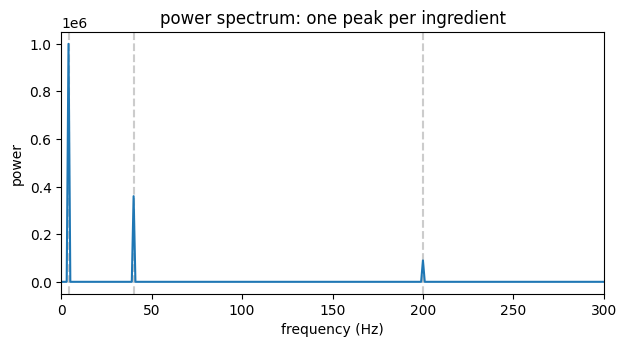

In [3]:
def power_spectrum(x, fs):
    spectrum = np.fft.rfft(x)                 # frequency content (complex)
    freqs = np.fft.rfftfreq(len(x), 1 / fs)   # the matching frequency axis (Hz)
    power = np.abs(spectrum) ** 2             # how much of each frequency
    return freqs, power

f, p = power_spectrum(signal, fs_demo)
plt.figure(figsize=(7, 3.4))
plt.plot(f, p); plt.xlim(0, 300)
for freq in (4, 40, 200):
    plt.axvline(freq, color="0.8", ls="--", zorder=0)
plt.xlabel("frequency (Hz)"); plt.ylabel("power")
plt.title("power spectrum: one peak per ingredient"); plt.show()

Three peaks, at exactly the three frequencies we put in. That's the power spectrum's
job: it reveals the hidden frequency ingredients of any signal.

### What does a *real* recording look like?

Now the same view, on one channel of our actual recording. (`welch` below is just a
smoothed power spectrum — the same idea as Exercise 1, averaged over short windows to
tame the noise.)

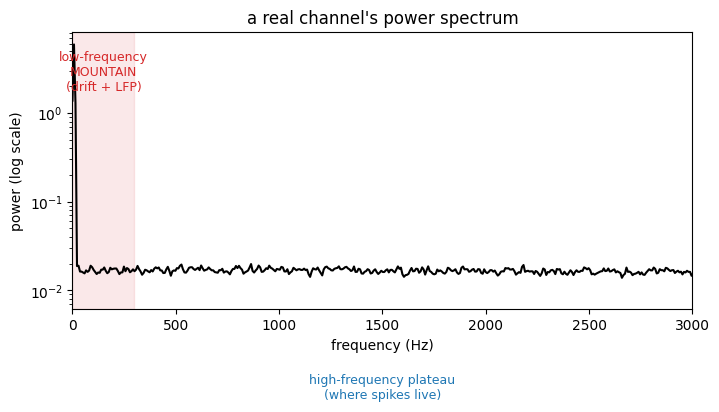

In [4]:
from scipy.signal import welch

f_real, p_real = welch(raw[:, 10], fs=rec.fs, nperseg=4096)
plt.figure(figsize=(8, 3.6))
plt.semilogy(f_real, p_real, color="k")
plt.axvspan(0, 300, color="tab:red", alpha=0.10)
plt.text(150, p_real.max() * 0.3, "low-frequency\nMOUNTAIN\n(drift + LFP)",
         ha="center", fontsize=9, color="tab:red")
plt.text(1500, p_real.max() * 1e-4, "high-frequency plateau\n(where spikes live)",
         ha="center", fontsize=9, color="tab:blue")
plt.xlim(0, 3000); plt.xlabel("frequency (Hz)"); plt.ylabel("power (log scale)")
plt.title("a real channel's power spectrum"); plt.show()

Two features stand out (the y-axis is logarithmic, so each gridline is 10× the one
below). At **low frequencies** there's a huge **mountain** of power — the slow
**drift** and **local field potential (LFP)**, the shared background swings of the
tissue. At **higher frequencies** there's a much lower, broad **plateau** — this is
where the **spikes** live, because a spike is a fast event and its energy is spread
across high frequencies. Our whole job in this section: **keep the plateau, throw away
the mountain.** The tool for "keep some frequencies, remove others" is a *filter*.

## 2. Filtering: keep some frequencies, remove others

A **filter** passes some frequencies and blocks others. The frequency where it
switches over is its **cutoff frequency**. There are three basic shapes — here is the
**frequency response** of each (the gain it applies at each frequency: 1 = kept,
0 = removed), with the cutoff(s) marked:

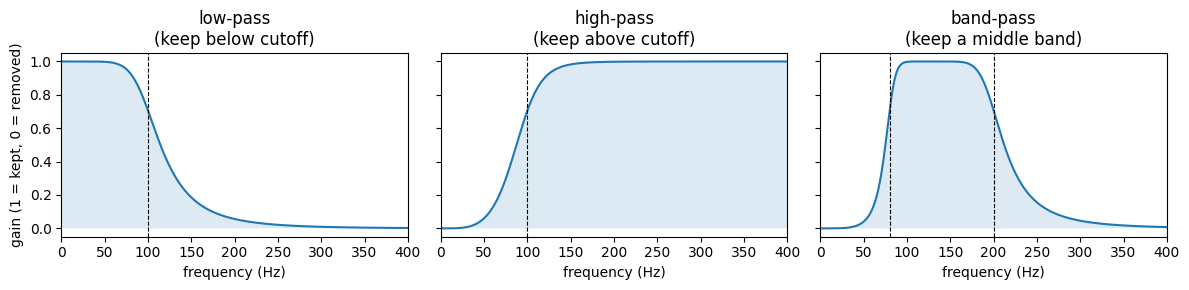

In [5]:
from scipy.signal import butter, freqz

fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
specs = [("low", 100, "low-pass\n(keep below cutoff)"),
         ("high", 100, "high-pass\n(keep above cutoff)"),
         ("band", [80, 200], "band-pass\n(keep a middle band)")]
for a, (kind, cut, title) in zip(ax, specs):
    num, den = butter(4, np.array(cut) / (fs_demo / 2), btype=kind)
    w, h = freqz(num, den, worN=2000, fs=fs_demo)
    a.plot(w, np.abs(h)); a.fill_between(w, np.abs(h), alpha=0.15)
    for c in np.atleast_1d(cut):
        a.axvline(c, color="k", ls="--", lw=0.8)
    a.set_title(title); a.set_xlim(0, 400); a.set_xlabel("frequency (Hz)")
ax[0].set_ylabel("gain (1 = kept, 0 = removed)")
plt.tight_layout(); plt.show()

Now watch a filter actually do this to our three-ingredient signal. A **high-pass** at
100 Hz should throw away the 4 Hz and 40 Hz waves and keep only the fast 200 Hz one; a
**low-pass** at 100 Hz should do the opposite.

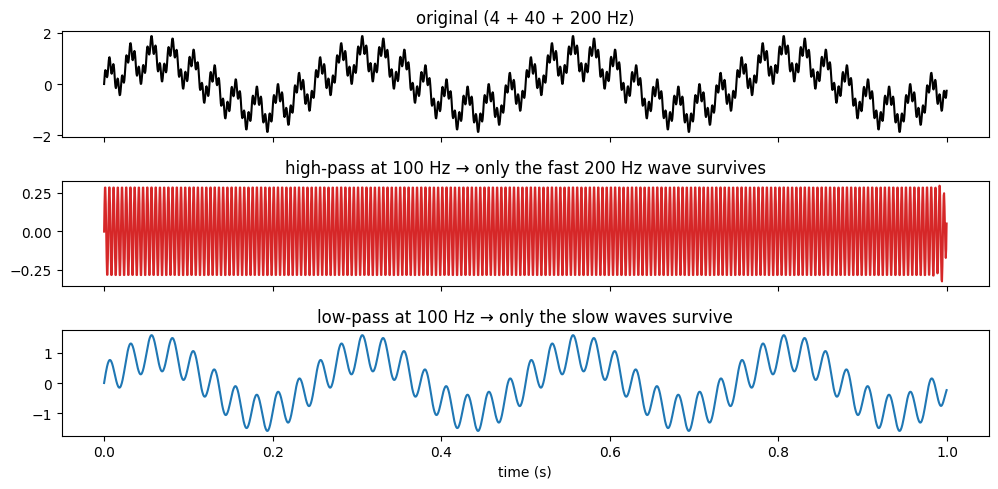

In [6]:
from scipy.signal import filtfilt

def apply_filter(x, fs, cutoff, kind):
    num, den = butter(4, cutoff / (fs / 2), btype=kind)
    return filtfilt(num, den, x)

hp = apply_filter(signal, fs_demo, 100, "high")   # keep fast
lp = apply_filter(signal, fs_demo, 100, "low")    # keep slow

fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, signal, "k"); ax[0].set_title("original (4 + 40 + 200 Hz)")
ax[1].plot(t, hp, "tab:red"); ax[1].set_title("high-pass at 100 Hz → only the fast 200 Hz wave survives")
ax[2].plot(t, lp, "tab:blue"); ax[2].set_title("low-pass at 100 Hz → only the slow waves survive")
ax[2].set_xlabel("time (s)"); plt.tight_layout(); plt.show()

Exactly as advertised. Filtering let us *pull apart* components that were added
together — which is precisely what we need, because spikes and drift live at different
frequencies.

## 3. The Butterworth filter

The responses above weren't perfect brick walls — they sloped through the cutoff
rather than switching instantly. That's unavoidable, and different **filter designs**
slope differently. The **Butterworth** is the standard workhorse: *maximally flat* in
the band it keeps (it doesn't distort those frequencies), at the cost of a gentle
transition. Two dials control it: the **cutoff frequency** and the **order** (how
*sharply* it switches).

To read filter responses properly we need one more idea: the **decibel (dB)**, a
logarithmic way to write gain. It's defined as $\text{dB} = 20\log_{10}(\text{gain})$,
so gain 1 (fully kept) is **0 dB**, gain $\tfrac12$ is about $-6$ dB, and gain
$1/\sqrt2 \approx 0.707$ is about $-3$ dB. Why bother? On a linear axis a gain of
0.001 and 0.00001 both look like flat zero; in dB they're $-60$ and $-100$, clearly
different — so dB lets us *see* deep into the stopband. Here is the same Butterworth
high-pass on both scales:

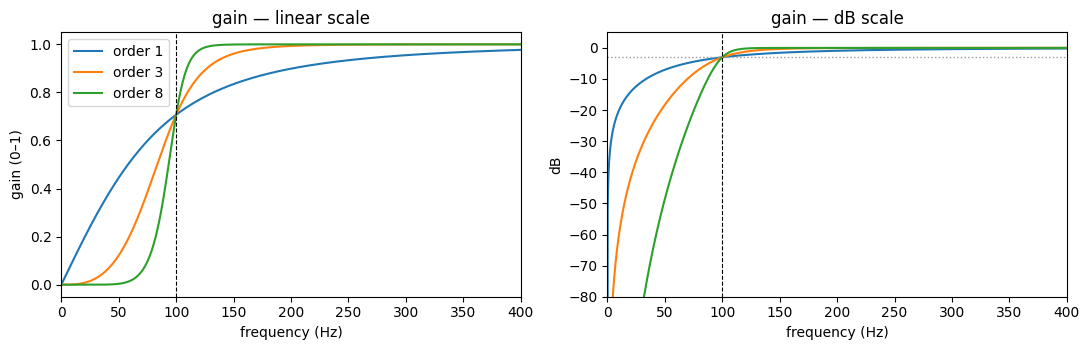

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for order in (1, 3, 8):
    num, den = butter(order, 100 / (fs_demo / 2), btype="high")
    w, h = freqz(num, den, worN=4000, fs=fs_demo)
    gain = np.abs(h)
    ax[0].plot(w, gain, label=f"order {order}")
    ax[1].plot(w, 20 * np.log10(gain + 1e-12), label=f"order {order}")
ax[0].set_title("gain — linear scale"); ax[0].set_ylabel("gain (0–1)")
ax[1].set_title("gain — dB scale"); ax[1].set_ylabel("dB"); ax[1].set_ylim(-80, 5)
ax[1].axhline(-3, color="0.6", ls=":", lw=1)                # the -3 dB point
for a in ax:
    a.axvline(100, color="k", ls="--", lw=0.8); a.set_xlim(0, 400); a.set_xlabel("frequency (Hz)")
ax[0].legend(); plt.tight_layout(); plt.show()

On the **linear** plot (left) the curves rise from 0 to 1 through the cutoff; higher
order = steeper. On the **dB** plot (right) you can see how deeply each one kills the
low frequencies — the order-8 filter drops far below $-60$ dB, invisible on the linear
axis. All curves pass through $-3$ dB (gain $1/\sqrt2$) at the cutoff; that's the
conventional definition of "the cutoff frequency." A **middle order (3–4)** is the
usual choice — sharp enough, without the ringing a very high order can add.

<details>
<summary><b>▸ Go deeper: the Butterworth response equation (optional)</b></summary>

Those S-curves have a one-line formula. A Butterworth filter of order $n$ with cutoff
$f_c$ has squared gain (low-pass form)

$$|H(f)|^2 \;=\; \frac{1}{1 + (f/f_c)^{2n}}.$$

Read off the behaviour: at $f = f_c$ the denominator is $2$, so the gain is
$1/\sqrt{2} \approx 0.707$ — that's the $-3$ dB point, **for every order**. As $n$
grows, $(f/f_c)^{2n}$ flips from $\approx 0$ to $\gg 1$ ever more abruptly around
$f_c$, sharpening the transition. "Maximally flat" is precise: this $|H|^2$ has the
most possible derivatives equal to zero at $f=0$, so the passband is as ripple-free as
any filter of that order can be. (The high-pass is the same with $f$ and $f_c$ swapped,
$|H|^2 = 1/(1+(f_c/f)^{2n})$.)
</details>

## 4. High-pass the recording

Now the real thing. We met the recording's spectrum in section 1: a low-frequency
**mountain** (drift + LFP) and a high-frequency **plateau** (spikes). A high-pass at
**300 Hz** — the standard cutoff for the Neuropixels AP band — keeps the plateau and
removes the mountain. First, in the **frequency** domain:

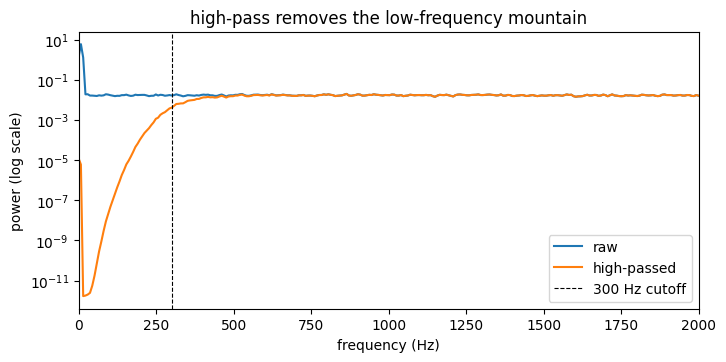

In [8]:
filt_hp = ps.highpass_filter(raw, rec.fs, cutoff=300)

f, praw = welch(raw[:, 10], fs=rec.fs, nperseg=4096)
f, php = welch(filt_hp[:, 10], fs=rec.fs, nperseg=4096)
plt.figure(figsize=(8, 3.6))
plt.semilogy(f, praw, label="raw")
plt.semilogy(f, php, label="high-passed")
plt.axvline(300, color="k", ls="--", lw=0.8, label="300 Hz cutoff")
plt.xlim(0, 2000); plt.xlabel("frequency (Hz)"); plt.ylabel("power (log scale)")
plt.legend(); plt.title("high-pass removes the low-frequency mountain"); plt.show()

Read this carefully: below 300 Hz the high-passed curve (orange) **plunges far down**.
That is *not* a dip in the data — it's the low-frequency mountain being **removed**,
its power pushed down to nearly nothing (the log axis reaches $10^{-11}$). Above
300 Hz the two curves lie on top of each other: the spikes are left completely
untouched. The same event in the **time** domain — the drifting baseline flattens out
and the spikes stand clear:

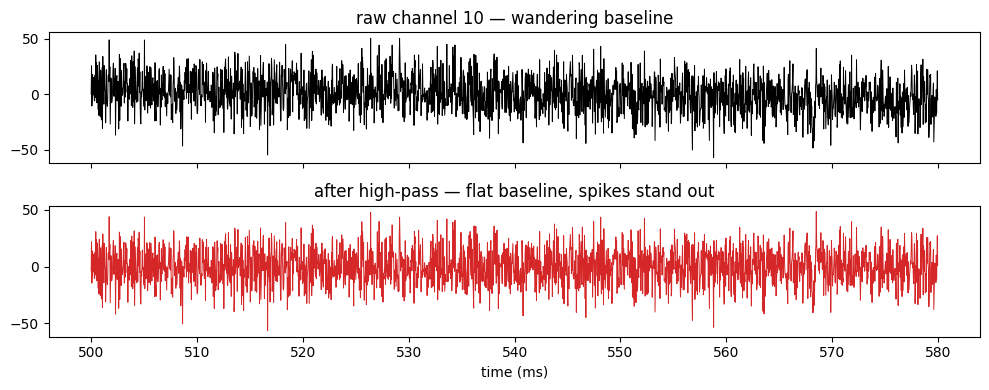

In [9]:
i0, i1 = int(0.50 * rec.fs), int(0.58 * rec.fs)
tt = np.arange(i0, i1) / rec.fs * 1e3
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].plot(tt, raw[i0:i1, 10], "k", lw=0.7); ax[0].set_title("raw channel 10 — wandering baseline")
ax[1].plot(tt, filt_hp[i0:i1, 10], "tab:red", lw=0.7)
ax[1].set_title("after high-pass — flat baseline, spikes stand out")
ax[1].set_xlabel("time (ms)"); plt.tight_layout(); plt.show()

## 5. Common average reference

Some artefacts appear *identically* on every channel — a movement, a reference
fluctuation. Because they're the same everywhere, we can estimate them by the
**across-channel average** at each moment and subtract it. But **which** average —
the mean or the median? It matters, and here's why.

A big spike is huge on its own channel but absent on the others. If we use the
**mean** as the reference, that one big value drags the average up, and subtracting it
then stamps a faint upside-down copy of the spike onto *every other channel* — an
artefact we just created. The **median** ignores the lone outlier, so it doesn't. See
it on a toy of 8 channels of noise with one big spike on channel 0:

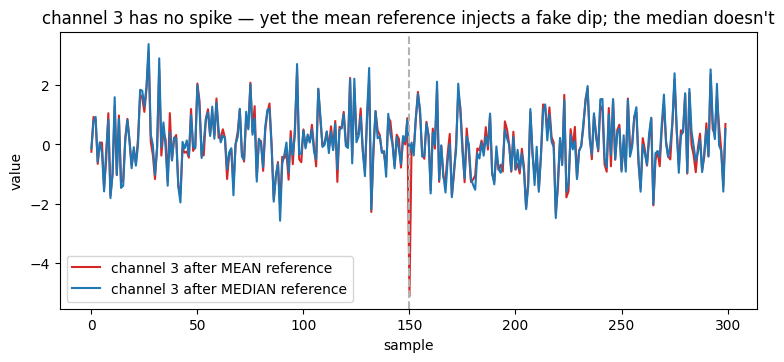

In [10]:
rng = np.random.default_rng(0)
toy = rng.normal(0, 1.0, size=(300, 8))
toy[150, 0] += 40                               # a big spike, on channel 0 only

mean_ref = toy - toy.mean(axis=1, keepdims=True)      # reference = mean across channels
median_ref = toy - np.median(toy, axis=1, keepdims=True)  # reference = median

plt.figure(figsize=(9, 3.6))
plt.plot(mean_ref[:, 3], color="tab:red", label="channel 3 after MEAN reference")
plt.plot(median_ref[:, 3], color="tab:blue", label="channel 3 after MEDIAN reference")
plt.axvline(150, color="0.7", ls="--")
plt.title("channel 3 has no spike — yet the mean reference injects a fake dip; the median doesn't")
plt.xlabel("sample"); plt.ylabel("value"); plt.legend(); plt.show()

Under the **mean** reference (red) channel 3 gets a spurious negative blip at exactly
the moment channel 0 spiked — a ghost spike we'd then have to worry about. Under the
**median** reference (blue) it stays flat. So we use the median.

**Exercise 2** *(~3 min · easy)*. Complete `common_average_reference`: subtract the median
across channels (axis 1) at every time sample.

> **Check / unstuck.** After CAR the per-sample median across channels should be ~0.
> Stuck? Use `ps.common_average_reference(filt_hp)`.

In [11]:
def common_average_reference(traces):
    return traces - np.median(traces, axis=1, keepdims=True)

filt = common_average_reference(filt_hp)
print("median across channels before CAR:", np.median(np.abs(np.median(filt_hp, axis=1))).round(2))
print("median across channels after  CAR:", np.median(np.abs(np.median(filt, axis=1))).round(4))

median across channels before CAR: 7.15


median across channels after  CAR: 0.0


## 6. Variance, covariance, and the shape of noise

One nuisance remains, the subtle one — but to see it we first need two everyday
statistics.

**Variance** measures how much a signal *wiggles* around its average: small variance =
nearly flat, large variance = big swings. Its square root is the **standard deviation**
$\sigma$ — the typical size of a wiggle, and the very "sigma" we'll set a detection
threshold in (Notebook 3).

**Covariance** compares *two* channels: when channel A is above its own average, does
channel B tend to be above its average too? If so they **co-vary**. The clearest way
to see it is to scatter one channel's voltage against another's, sample by sample, and
draw the **ellipse** that summarises the cloud's shape:

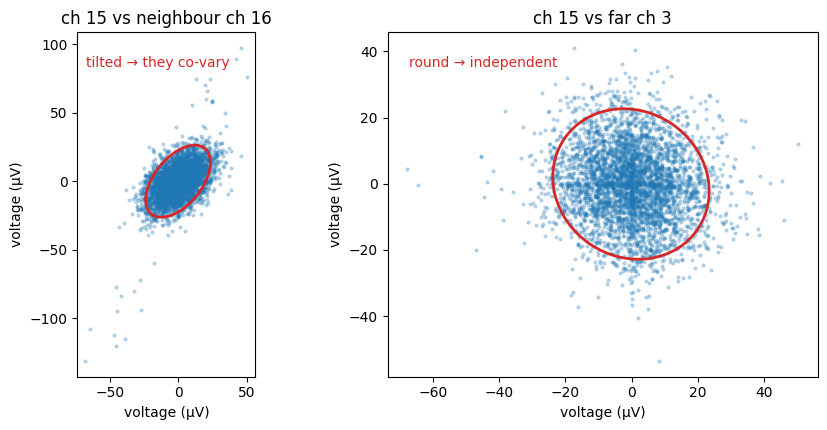

In [12]:
from matplotlib.patches import Ellipse

def draw_cov_ellipse(ax, xy, n_std=2.0, **kw):
    # draw the ellipse describing the covariance of the 2-column data `xy`
    C = np.cov(xy.T)
    vals, vecs = np.linalg.eigh(C)                  # axis lengths^2 and axis directions
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    width, height = 2 * n_std * np.sqrt(vals[::-1])
    ax.add_patch(Ellipse(xy.mean(0), width, height, angle=angle, fill=False, **kw))

rng = np.random.default_rng(0)
idx = rng.integers(0, len(filt), 4000)
ch, neighbour, far = 15, 16, 3
fig, ax = plt.subplots(1, 2, figsize=(9, 4.4))
for a, other, label in [(ax[0], neighbour, "neighbour"), (ax[1], far, "far")]:
    xy = np.column_stack([filt[idx, ch], filt[idx, other]])
    a.scatter(xy[:, 0], xy[:, 1], s=4, alpha=0.25)
    draw_cov_ellipse(a, xy, edgecolor="tab:red", lw=2)
    a.set_title(f"ch {ch} vs {label} ch {other}"); a.set_aspect("equal")
    a.set_xlabel("voltage (µV)"); a.set_ylabel("voltage (µV)")
ax[0].text(0.05, 0.9, "tilted → they co-vary", transform=ax[0].transAxes, color="tab:red")
ax[1].text(0.05, 0.9, "round → independent", transform=ax[1].transAxes, color="tab:red")
plt.tight_layout(); plt.show()

The ellipse *is* the covariance, drawn: for neighbouring channels it's **tilted and
stretched** along a diagonal — high on one tends to mean high on the other, because
they share much of the same noise. For far-apart channels it's a **round** blob —
knowing one tells you nothing about the other.

Now measure this for **every pair of channels at once** and collect the answers in a
grid: the **covariance matrix**. Entry $(i, j)$ is the covariance of channel $i$ with
channel $j$; the diagonal is each channel's own variance. Bright entries just off the
diagonal are the neighbour-correlations we just saw.

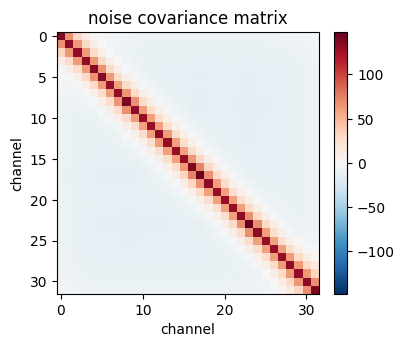

In [13]:
cov = ps.noise_covariance(filt)
ps.plotting.plot_covariance(cov, title="noise covariance matrix")
plt.show()

The bright band hugging the diagonal is the spatial correlation of the noise. That
correlation is a problem for detection: a fluctuation shared by five neighbouring
channels can masquerade as a big multi-channel event, and a threshold of "5 sigma"
means different things on channels whose noise is entangled. **Whitening** fixes it —
and it's easiest to *see* on the very cloud we just drew.

## 7. Whitening = decorrelate, then equalise

Whitening turns that **tilted** noise cloud into a **round** one, in two geometric
steps. Watch it happen on the two correlated channels from the last section:

1. **Rotate to decorrelate.** Spin the cloud so its long and short axes line up with
   the coordinate axes. In these new coordinates the two channels no longer co-vary —
   the tilt is gone, leaving an *upright* ellipse.
2. **Scale to equalise variance.** Stretch/squash each axis so the spread is the same
   in every direction — the ellipse becomes a **circle**. Now the noise is equal in
   all directions and uncorrelated: exactly "white."

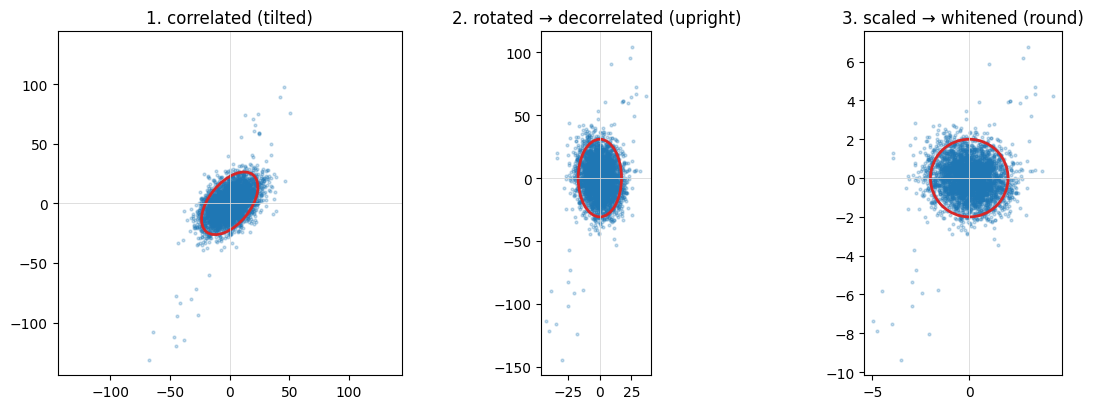

In [14]:
xy = np.column_stack([filt[idx, ch], filt[idx, neighbour]])
xy = xy - xy.mean(0)
vals, vecs = np.linalg.eigh(np.cov(xy.T))     # vecs = the cloud's axes, vals = variance along each

rotated = xy @ vecs                            # step 1: rotate onto the axes → decorrelated
whitened_2d = rotated / np.sqrt(vals)          # step 2: scale each axis to variance 1 → whitened

lim = np.abs(xy).max() * 1.1
fig, ax = plt.subplots(1, 3, figsize=(12, 4.2))
for a, data, title in zip(
        ax, [xy, rotated, whitened_2d],
        ["1. correlated (tilted)", "2. rotated → decorrelated (upright)", "3. scaled → whitened (round)"]):
    a.scatter(data[:, 0], data[:, 1], s=4, alpha=0.25)
    draw_cov_ellipse(a, data, edgecolor="tab:red", lw=2)
    a.axhline(0, color="0.85", lw=0.6); a.axvline(0, color="0.85", lw=0.6)
    a.set_aspect("equal"); a.set_title(title)
ax[0].set_xlim(-lim, lim); ax[0].set_ylim(-lim, lim)
plt.tight_layout(); plt.show()

Tilted → upright → round. The **rotation** came from the covariance matrix's
**eigenvectors** (the cloud's natural axes), and the **scaling** from its
**eigenvalues** (the variance along each axis). Whitening the real data does exactly
this, but for all 32 channels at once — one rotation and one rescaling in
32-dimensional space, packaged into a single matrix $W$.

**Exercise 3** *(~7 min · meaty)*. Complete `whitening_matrix`. `np.linalg.eigh` hands you the
axes (`vecs`) and the variances along them (`vals`); build the matrix that **rotates**
onto the axes, **scales** each by $1/\sqrt{\text{variance}}$, and **rotates back** —
that is `vecs @ diag(1/sqrt(vals)) @ vecs.T`. Then we apply it and confirm the
covariance is now clean.

> **Check / unstuck.** After whitening, the covariance grid should be a bright diagonal
> with near-zero (blank) off-diagonal. Stuck? Use `ps.whitening_matrix(cov)`.

<details>
<summary><b>▸ Go deeper: the whitening matrix in symbols (optional)</b></summary>

We want a matrix $W$ so the transformed noise $z = Wn$ has covariance equal to the
identity — unit variance on every channel, zero correlation between them:
$\mathrm{Cov}(z) = W\,C\,W^{\top} = I$. Eigen-decomposing the (symmetric) covariance,
$C = V\Lambda V^{\top}$, the symmetric square root

$$W = C^{-1/2} = V\,\Lambda^{-1/2}\,V^{\top}$$

does it: $W C W^{\top} = V\Lambda^{-1/2}V^{\top}V\Lambda V^{\top}V\Lambda^{-1/2}V^{\top}
= V\Lambda^{-1/2}\Lambda\Lambda^{-1/2}V^{\top} = VV^{\top} = I$. Read left to right,
$V^{\top}$ is the **rotate onto the axes**, $\Lambda^{-1/2}$ is the **scale to unit
variance**, and $V$ **rotates back** — the exact three moves the pictures showed, in
32 dimensions. (Rotating back, rather than stopping after the scale, is the "ZCA"
choice; it keeps channels in place instead of leaving the data spun into the
eigenbasis. The $\epsilon$ in the code floors tiny eigenvalues, since $1/\sqrt{\lambda}$
would explode along near-zero-variance directions.) This also connects to **Notebook
6**: the optimal detector for a template $s$ in noise $C$ is $s^{\top}C^{-1}x$;
whitening first turns that into a plain template match.
</details>

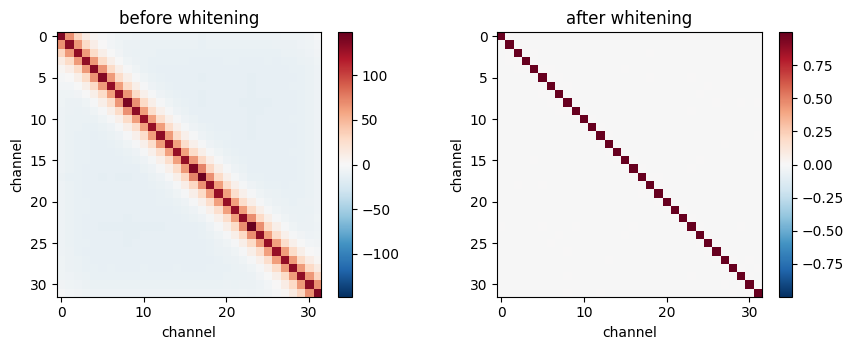

mean |off-diagonal| before: 13.684
mean |off-diagonal| after : 0.0


In [15]:
def whitening_matrix(cov, eps=1e-6):
    vals, vecs = np.linalg.eigh(cov)          # variances (vals) and axes (vecs)
    reg = eps * vals.max()                     # floor tiny eigenvalues
    return vecs @ np.diag(1.0 / np.sqrt(vals + reg)) @ vecs.T

W = whitening_matrix(cov)
whitened = filt @ W
cov_after = ps.noise_covariance(whitened)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
ps.plotting.plot_covariance(cov, ax=axes[0], title="before whitening")
ps.plotting.plot_covariance(cov_after, ax=axes[1], title="after whitening")
plt.tight_layout(); plt.show()
print("mean |off-diagonal| before:", round(np.abs(cov - np.diag(np.diag(cov))).mean(), 3))
print("mean |off-diagonal| after :", round(np.abs(cov_after - np.diag(np.diag(cov_after))).mean(), 3))

The off-diagonal correlations collapse: whitened noise is spatially flat, so a
detection threshold means the same thing on every channel.

> **Worth planting for Notebook 4.** We just used the covariance's **eigenvectors and
> eigenvalues** — the cloud's axes and how far it stretches along each. That exact
> tool, applied to *spike shapes* instead of noise, is **PCA** (Notebook 4): whitening
> uses the axes to round a cloud out; PCA uses them to summarise a spike in a couple of
> numbers.

## Putting it together

The whole pipeline — high-pass → CAR → whiten — is `ps.preprocess`. It returns two
things we'll both use: the **whitened** traces (for *detecting* spikes, where a
uniform threshold is what we want) and the **filtered** traces (high-passed and CAR'd
but not whitened, in real microvolts, where a spike's spatial footprint is undistorted
— the right place to *measure* waveforms and build templates).

whitened: (600000, 32)  filtered: (600000, 32)


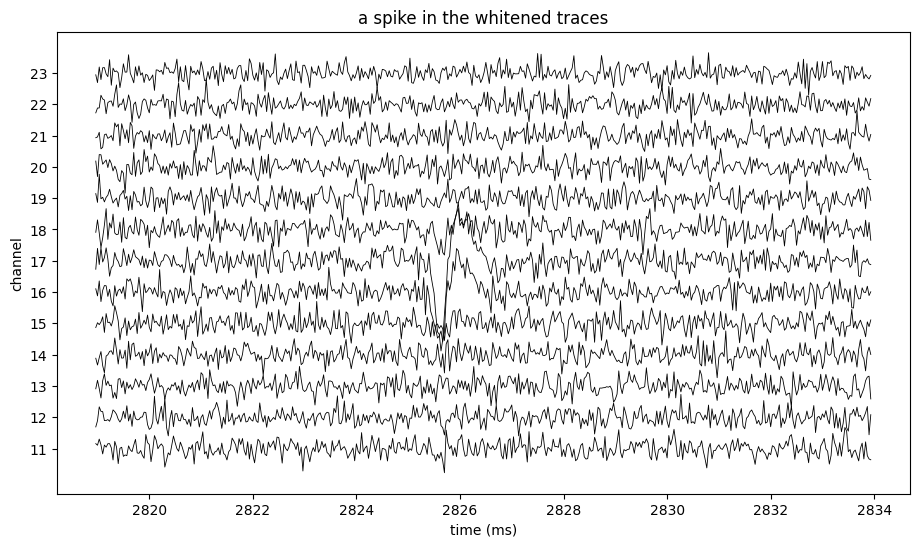

In [16]:
whitened, filtered, W = ps.preprocess(rec)
print("whitened:", whitened.shape, " filtered:", filtered.shape)

# The same spike, now clearly above the flat whitened noise.
gt = rec.ground_truth
u = int(np.argmax(gt.unit_amplitude)); t = gt.spike_times[gt.spike_labels == u][5]
pc = ps.peak_channel(gt.templates[u]); lo = max(0, pc - 6)
ps.plotting.plot_signal(whitened, rec.fs, channels=range(lo, lo + 13),
                        t0=(t - 200) / rec.fs, t1=(t + 250) / rec.fs,
                        title="a spike in the whitened traces")
plt.show()

## Wrap-up

You learned to see a signal as a **mixture of frequencies** (the Fourier view and the
power spectrum), what a **filter** and a **Butterworth** filter are (and how to read a
response in **dB**), and what **variance** and **covariance** mean — then used them:
high-pass killed the low-frequency mountain, the median-based CAR removed shared
artefacts without injecting ghosts, and whitening rotated-and-scaled the noise cloud
round so a threshold is meaningful everywhere.

**Next (Notebook 3 — detection):** put a threshold on these whitened traces, find the
crossings, and cut out a snippet around each detected spike.